In [1]:
import numpy as np
import matplotlib as mpl
mpl.rcParams['font.size'] = 14
import matplotlib.pyplot as plt

from core_krook import (
    run_timestepping,
)
from diagnostics import (
    compute_gamma,
    compute_gamma_krook,
    plot_initial_velocity_distribution,
    plot_full_f_velocity_distribution,
)

lblSize        = 14
ttlSize        = 16
tickSize       = 12   
lgdSize        = 12
txtSize        = 14   

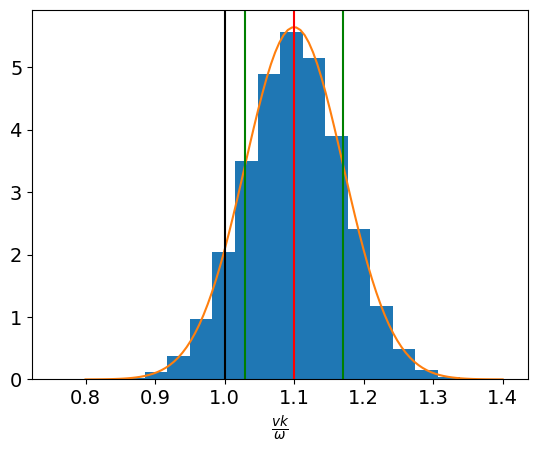

In [6]:
sim_params = {
    "E_c": 1e-6,  # initial E_c (cosine component)
    "E_s": -1e-6,  # initial E_s (sine component)
    "nb_over_ne": 3e-5,  # coupling constant
    "n_steps": 50000,  # number of timesteps
    "dt": 0.1,  # timestep (normalized by wave period)
    "n_particles": 500000,  # number of particles
    "vb": 0.1,  # beam thermal velocity over wave phase velocity
    "ub": 1.1,  # beam flow velocity over wave phase velocity
    "splitting_method": "strang",  # 'strang' or 'trotter'
    "method": "linear",  # 'linear' or 'nonlinear'
    "full_f": False,  # whether to use full distribution function (only for nonlinear)
    "beta": 1e-4,
}

fig, ax = plot_initial_velocity_distribution(sim_params)


In [7]:
gamma_krook = compute_gamma_krook(sim_params)
#
print('Predicted linear growth rate with the effect of a Krook-type collision operator: ', gamma_krook)

gamma = compute_gamma(sim_params)

print('Predicted linear growth rate: ', gamma)
print('Predicted nonlinear saturated amplitude: ', gamma * gamma * (3.2 * 3.2))

Predicted linear growth rate with the effect of a Krook-type collision operator:  0.001953379362562048
Predicted linear growth rate:  0.0019561479965198745
Predicted nonlinear saturated amplitude:  3.918351343911649e-05


In [4]:
beta = '1e-1'
sim_outputs = run_timestepping(sim_params)
np.savez('sim_outputs_beta_'+beta+'.npz', **sim_outputs)

E_c = sim_outputs["E_c"]
E_s = sim_outputs["E_s"]
x = sim_outputs["x"]
v = sim_outputs["v"]
w = sim_outputs["w"]

In [ ]:
# Restart here if you want to load the simulation outputs from a file instead of running the simulation again
beta = '1e-3' # Please specify the value of beta
sim_outputs = np.load(f'sim_outputs_beta_'+beta+'.npz')

E_c = sim_outputs["E_c"]
E_s = sim_outputs["E_s"]
x = sim_outputs["x"]
v = sim_outputs["v"]
w = sim_outputs["w"]

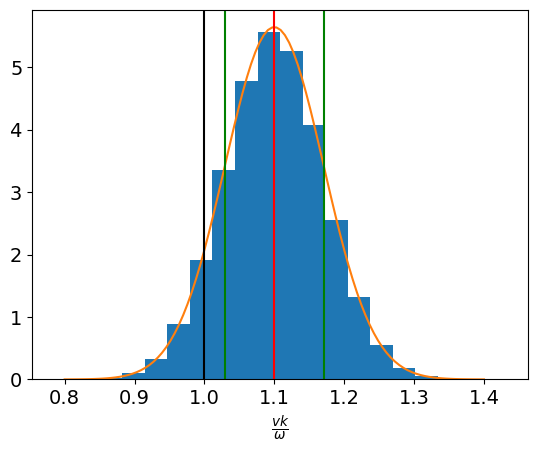

In [5]:
fig, ax = plot_full_f_velocity_distribution(v, sim_params["ub"], sim_params["vb"])

E_c_hist = sim_outputs["E_c_hist"]
E_s_hist = sim_outputs["E_s_hist"]
E_amp_hist = sim_outputs["E_amp_hist"]
phi_hist = sim_outputs["phi_hist"]
time = sim_outputs["time"]

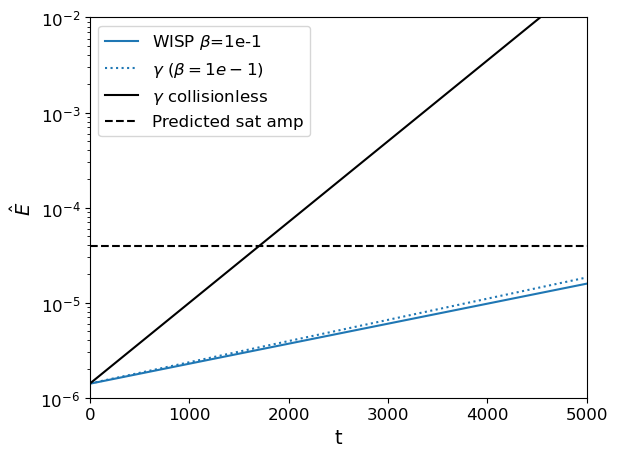

In [6]:
plt.figure()
plt.semilogy(time, np.abs(E_amp_hist), color='tab:blue', label=rf'WISP $\beta$={beta}')
#plt.semilogy(time, np.abs(E_amp_hist), color='tab:blue', label='WISP collisionless')
plt.semilogy(time, np.abs(E_amp_hist[0])*np.exp(gamma_krook*time), color='tab:blue', linestyle=':', label=rf'$\gamma~(\beta={beta})$')
plt.semilogy(time, np.abs(E_amp_hist[0])*np.exp(gamma*time), color='k', label=r'$\gamma$ collisionless')
plt.axhline(gamma * gamma * (3.2 * 3.2), color='k', linestyle='--', label='Predicted sat amp')
plt.legend(fontsize=lgdSize)
plt.xlabel('t', fontsize=lblSize)
plt.ylabel(r'$\hat{E}$', fontsize=lblSize)
plt.xlim([0,5000])
plt.ylim([1e-6,1e-2])
plt.tick_params(labelsize=tickSize)
plt.tight_layout()

plt.savefig
plt.savefig('linear_delta_f_growth_rate_beta_'+beta+'.png', dpi=300)

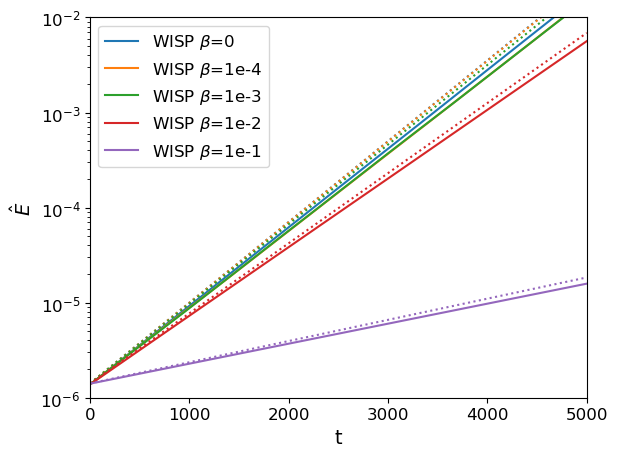

In [17]:
beta = ['0', '1e-4', '1e-3', '1e-2', '1e-1']
gamma_krook = [0.0019561479965198745, 0.001953379362562048, 0.0019286277593024395, 0.0016979115363176265, 0.0005132597438990682]

plt.figure()
for i in range(len(beta)):
    E_amp_hist = np.load(f'sim_outputs_beta_'+beta[i]+'.npz')["E_amp_hist"]
    time = np.load(f'sim_outputs_beta_'+beta[i]+'.npz')["time"]
    line1, = plt.semilogy(time, np.abs(E_amp_hist), label=rf'WISP $\beta$={beta[i]}')
    plt.semilogy(time, np.abs(E_amp_hist[0])*np.exp(gamma_krook[i]*time), color=line1.get_color(), linestyle=':')
plt.legend(fontsize=lgdSize)
plt.xlabel('t', fontsize=lblSize)
plt.ylabel(r'$\hat{E}$', fontsize=lblSize)
plt.xlim([0,5000])
plt.ylim([1e-6,1e-2])
plt.tick_params(labelsize=tickSize)
plt.tight_layout()

plt.savefig
plt.savefig('linear_delta_f_growth_rate_krook_only.png', dpi=300)